# Data parsing and exploration for learnedcache

In [37]:
import csv

def parse_log_to_csv(input_filepath, output_filepath):
    """
    Parses a log file line-by-line and writes directly to a CSV 
    """
    with open(input_filepath, 'r') as infile:
        first_line = infile.readline()
        if not first_line:
            print("The file is empty.")
            return

        def parse_line(line):
            return dict(item.split('=') for item in line.strip().split() if '=' in item)

        initial_data = parse_line(first_line)
        fieldnames = list(initial_data.keys())

        with open(output_filepath, 'w', newline='') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            
            writer.writerow(initial_data)

            for line in infile:
                if line.strip():
                    row_data = parse_line(line)
                    writer.writerow(row_data)

    print(f"Done! Processed data saved to: {output_filepath}")

In [ ]:
parse_log_to_csv('data/tracer-cache-access.log', 'data/cache-access.csv')

Done! Processed data saved to: cache-access.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/cache-access.csv')

In [40]:
df.head()

,t,d,i,o,s,w,z,r
0,0,253:0,1,790,0,0,0,28
1,0,253:0,1,791,0,0,0,28
2,0,0:3,265289728,12582923,0,0,67641540608,28
3,0,0:3,265289728,3670230,0,0,67641540608,28
4,0,0:3,265289728,3670421,0,0,67641540608,26


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2155708 entries, 0 to 2155707
Data columns (total 8 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   t       int64 
 1   d       object
 2   i       int64 
 3   o       int64 
 4   s       int64 
 5   w       int64 
 6   z       int64 
 7   r       int64 
dtypes: int64(7), object(1)
memory usage: 131.6+ MB


In [42]:
pd.set_option('display.precision', 20)
df.describe()

,t,i,o,s,w,z,r
count,2.15570800000000000000e+06,2.15570800000000000000e+06,2.15570800000000000000e+06,2155708.0,2155708.0,2.15570800000000000000e+06,2.15570800000000000000e+06
mean,2.55700296282612371445e+09,1.14822894293656185269e+08,1.66672368182610999793e+06,0.0,0.0,2.91559226776532135010e+10,2.64497705626179424598e+01
std,6.05461488040445232391e+09,1.30963232984397202730e+08,2.15582206012814259157e+06,0.0,0.0,3.34970440704494781494e+10,4.75373680640208107206e+00
min,0.00000000000000000000e+00,1.00000000000000000000e+00,0.00000000000000000000e+00,0.0,0.0,0.00000000000000000000e+00,0.00000000000000000000e+00
25%,2.14910000000000000000e+04,9.21053000000000000000e+05,1.70000000000000000000e+01,0.0,0.0,1.48982000000000000000e+05,2.60000000000000000000e+01
50%,1.00939165000000000000e+07,9.24976000000000000000e+05,7.40000000000000000000e+01,0.0,0.0,3.60117000000000000000e+05,2.80000000000000000000e+01
75%,1.85371948950000000000e+09,2.65289728000000000000e+08,3.67024300000000000000e+06,0.0,0.0,6.76415406080000000000e+10,2.80000000000000000000e+01
max,5.71730554270000000000e+10,2.65289728000000000000e+08,1.57286440000000000000e+07,0.0,0.0,6.76415406080000000000e+10,3.10000000000000000000e+01


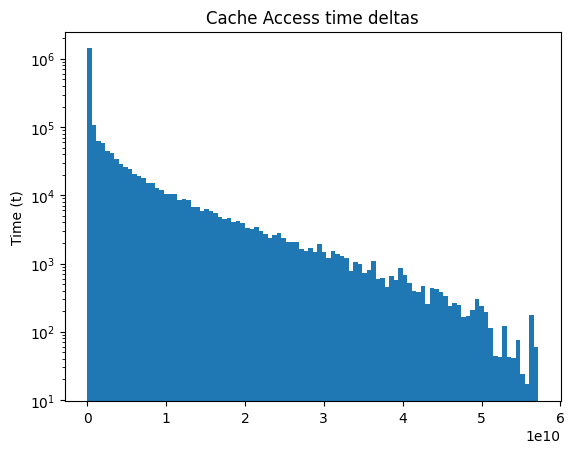

In [43]:
df['t'].plot(title='Cache Access time deltas', ylabel='Time (t)', kind='hist', bins=100)
plt.yscale('log')
plt.show()

In [44]:
highest_10_unique_times = df['t'].drop_duplicates().nlargest(10)
highest_10_unique_times

2155381    57173055427
2155382    57173051319
2155383    57173046590
2155421    57173032443
2155429    57173010551
2155430    57173010470
2155431    57173009489
2155432    57173008256
2155433    57173006673
2155474    57172992918
Name: t, dtype: int64